# YOLO Object Detection

In this notebook, we build and evaluate an object detection model
using YOLO on the SmartVision dataset.

The objective is to detect objects and identify their bounding boxes
within images.

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# connecting to drive

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [ ]:
import os

print("Contents of MyDrive:")
print(os.listdir("/content/drive/MyDrive")[:50])

Contents of MyDrive:
['classification_clean.zip', 'Colab Notebooks', 'mobilenet_v2_best.pth', 'mobilenetv2_exp2_best.pth', 'mobilenetv2_exp3_best.pth', 'mobilenetv2_exp4_best.pth', 'mobilenetv2_exp5_best.pth', 'EfficientNet_exp_1.pth', 'EfficientNet_exp_2.pth', 'detection.zip']


### Inspecting the Raw Detection Dataset

The detection dataset is stored as a ZIP file in Google Drive.

Before extracting and preprocessing the dataset, we inspect the ZIP contents to understand its directory structure, including the image files and annotation/label files.

This step helps us identify the correct dataset structure before performing duplicate detection and data validation.

In [ ]:
# unzipping detection folder

import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/detection.zip")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    files = zip_ref.namelist()

print("Total files inside ZIP:", len(files))

print("\nFirst 30 files:")
for f in files[:30]:
    print(f)

Total files inside ZIP: 15278

First 30 files:
detection/
detection/data.yaml
detection/images/
detection/images/image_000000.jpg
detection/images/image_000001.jpg
detection/images/image_000002.jpg
detection/images/image_000003.jpg
detection/images/image_000004.jpg
detection/images/image_000005.jpg
detection/images/image_000006.jpg
detection/images/image_000007.jpg
detection/images/image_000008.jpg
detection/images/image_000009.jpg
detection/images/image_000010.jpg
detection/images/image_000011.jpg
detection/images/image_000012.jpg
detection/images/image_000013.jpg
detection/images/image_000014.jpg
detection/images/image_000015.jpg
detection/images/image_000016.jpg
detection/images/image_000017.jpg
detection/images/image_000018.jpg
detection/images/image_000019.jpg
detection/images/image_000020.jpg
detection/images/image_000021.jpg
detection/images/image_000022.jpg
detection/images/image_000023.jpg
detection/images/image_000024.jpg
detection/images/image_000025.jpg
detection/images/ima

### Inspecting the Detection Dataset Structure

The raw detection dataset contains images and YOLO annotation files.

Before preprocessing, we inspect the directory structure to identify:

- Image files
- YOLO label files
- Dataset configuration files
- Any additional folders

Understanding this structure is necessary before performing duplicate detection and annotation validation.

In [ ]:
from collections import Counter

# Remove the filenames and count the directory structure
folders = []

for f in files:
    parts = Path(f).parts

    if len(parts) > 1:
        folders.append("/".join(parts[:-1]) + "/")

folder_counts = Counter(folders)

print("Dataset folder structure:\n")

for folder, count in sorted(folder_counts.items()):
    print(f"{folder:<50} {count} files")

Dataset folder structure:

detection/                                         3 files
detection/images/                                  7637 files
detection/labels/                                  7637 files


### Extracting the Raw Detection Dataset

The YOLO detection dataset is stored as a ZIP archive in Google Drive.

The archive is extracted into the Colab runtime so that the images and annotation files can be inspected and validated efficiently.

The raw dataset contains:

- `images/` — input images
- `labels/` — YOLO annotation files
- `data.yaml` — dataset configuration

The original ZIP file in Google Drive is preserved as a backup.

In [ ]:
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/detection.zip")
EXTRACT_DIR = Path("/content/detection_raw")

# Extract only if not already extracted
if not EXTRACT_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully!")
print(" Location:", EXTRACT_DIR)

# Check extracted structure
dataset_dir = EXTRACT_DIR / "detection"

print("\nContents:")
for item in dataset_dir.iterdir():
    print(" -", item.name)

Dataset extracted successfully!
 Location: /content/detection_raw

Contents:
 - images
 - labels
 - data.yaml


### Image and Label Correspondence Check

In an object detection dataset, every image should have its corresponding YOLO annotation file.

For example:

`image_000123.jpg` → `image_000123.txt`

This check compares the filename stems of the image and label files.

We identify:

- Images without annotation files
- Annotation files without corresponding images

A correct one-to-one relationship is required before continuing with dataset cleaning and YOLO training.

In [ ]:
from pathlib import Path

IMAGES_DIR = Path("/content/detection_raw/detection/images")
LABELS_DIR = Path("/content/detection_raw/detection/labels")

image_stems = {p.stem for p in IMAGES_DIR.glob("*.jpg")}
label_stems = {p.stem for p in LABELS_DIR.glob("*.txt")}

images_without_labels = image_stems - label_stems
labels_without_images = label_stems - image_stems

print("=" * 60)
print("🔍 IMAGE ↔ LABEL MATCHING CHECK")
print("=" * 60)

print(f"Total images : {len(image_stems)}")
print(f"Total labels : {len(label_stems)}")

print(f"\nImages without labels : {len(images_without_labels)}")
print(f"Labels without images : {len(labels_without_images)}")

if len(images_without_labels) == 0 and len(labels_without_images) == 0:
    print("\n✅ PERFECT MATCH!")
    print("Every image has a corresponding YOLO label.")
else:
    print("\n⚠️ MISMATCH FOUND!")

    if images_without_labels:
        print("\nExamples of images without labels:")
        for x in sorted(images_without_labels)[:10]:
            print(x)

    if labels_without_images:
        print("\nExamples of labels without images:")
        for x in sorted(labels_without_images)[:10]:
            print(x)

🔍 IMAGE ↔ LABEL MATCHING CHECK
Total images : 7637
Total labels : 7637

Images without labels : 0
Labels without images : 0

✅ PERFECT MATCH!
Every image has a corresponding YOLO label.


### Exact Duplicate Image Detection

Before creating the cleaned detection dataset, exact duplicate images are identified using MD5 file hashes.

Images with identical binary content produce the same hash value.

This allows us to identify:

- Unique images
- Duplicate groups
- The total number of duplicate files

No files are deleted during this step.

The duplicate analysis is performed first so that we can review the results before creating the cleaned dataset.

In [ ]:
import hashlib
from collections import defaultdict
from pathlib import Path

IMAGES_DIR = Path("/content/detection_raw/detection/images")

hash_to_files = defaultdict(list)

print("🔍 Calculating image hashes...")
print(f"Total images: {len(list(IMAGES_DIR.glob('*.jpg')))}")

for image_path in IMAGES_DIR.glob("*.jpg"):

    with open(image_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()

    hash_to_files[file_hash].append(image_path)

# Find duplicate groups
duplicate_groups = {
    file_hash: paths
    for file_hash, paths in hash_to_files.items()
    if len(paths) > 1
}

total_duplicate_files = sum(
    len(paths) - 1
    for paths in duplicate_groups.values()
)

print("\n" + "=" * 60)
print("📊 DUPLICATE IMAGE ANALYSIS")
print("=" * 60)

print(f"Total images          : {len(list(IMAGES_DIR.glob('*.jpg')))}")
print(f"Unique image contents : {len(hash_to_files)}")
print(f"Duplicate groups      : {len(duplicate_groups)}")
print(f"Duplicate files       : {total_duplicate_files}")

if duplicate_groups:
    print("\n⚠️ Duplicate images found!")

    print("\nFirst 10 duplicate groups:\n")

    for i, (file_hash, paths) in enumerate(duplicate_groups.items()):

        if i >= 10:
            break

        print(f"Group {i + 1}:")
        for path in paths:
            print("   ", path.name)

else:
    print("\n✅ No exact duplicate images found!")

🔍 Calculating image hashes...
Total images: 7637

📊 DUPLICATE IMAGE ANALYSIS
Total images          : 7637
Unique image contents : 2995
Duplicate groups      : 1377
Duplicate files       : 4642

⚠️ Duplicate images found!

First 10 duplicate groups:

Group 1:
    image_005560.jpg
    image_005559.jpg
    image_005558.jpg
Group 2:
    image_004572.jpg
    image_004569.jpg
    image_004570.jpg
    image_004571.jpg
    image_004573.jpg
    image_004354.jpg
    image_004568.jpg
    image_004566.jpg
    image_004567.jpg
Group 3:
    image_006728.jpg
    image_006726.jpg
    image_006721.jpg
    image_006727.jpg
    image_006724.jpg
    image_006722.jpg
    image_006723.jpg
    image_006719.jpg
    image_006729.jpg
    image_006720.jpg
    image_006725.jpg
    image_002933.jpg
Group 4:
    image_000354.jpg
    image_000358.jpg
    image_000359.jpg
    image_000353.jpg
    image_000350.jpg
    image_000357.jpg
    image_000355.jpg
    image_000356.jpg
    image_000352.jpg
    image_000351.jpg


### Duplicate Image Annotation Analysis

Identical images may have multiple filenames in the raw detection dataset.

Before removing duplicate images, their corresponding YOLO annotation files are compared.

This ensures that duplicate removal does not accidentally discard different object annotations associated with the same image content.

Duplicate groups with identical annotations can safely be reduced to a single image-label pair.

Groups with different annotations require further investigation before removal.

In [ ]:
from collections import Counter

LABELS_DIR = Path("/content/detection_raw/detection/labels")

duplicate_annotation_analysis = []

for file_hash, image_paths in duplicate_groups.items():

    label_contents = {}

    for image_path in image_paths:

        label_path = LABELS_DIR / f"{image_path.stem}.txt"

        with open(label_path, "r") as f:
            content = f.read().strip()

        label_contents[image_path.name] = content

    unique_annotations = set(label_contents.values())

    duplicate_annotation_analysis.append(
        {
            "image_hash": file_hash,
            "images": image_paths,
            "unique_annotations": len(unique_annotations),
            "annotations": label_contents
        }
    )


# Count groups
same_annotation_groups = sum(
    1
    for group in duplicate_annotation_analysis
    if group["unique_annotations"] == 1
)

different_annotation_groups = sum(
    1
    for group in duplicate_annotation_analysis
    if group["unique_annotations"] > 1
)

print("=" * 60)
print("🔎 DUPLICATE ANNOTATION ANALYSIS")
print("=" * 60)

print(f"Duplicate image groups       : {len(duplicate_groups)}")
print(f"Same annotation groups       : {same_annotation_groups}")
print(f"Different annotation groups  : {different_annotation_groups}")

🔎 DUPLICATE ANNOTATION ANALYSIS
Duplicate image groups       : 1377
Same annotation groups       : 1377
Different annotation groups  : 0


### Creating the Clean Detection Dataset

The duplicate analysis identified 1,377 groups of identical images.

All duplicate groups were verified to have identical YOLO annotations. Therefore, one copy of each unique image and its corresponding annotation is retained.

The original raw dataset is preserved.

A separate cleaned dataset is created containing only unique image-label pairs.

Expected result:

- Original pairs: 7,637
- Unique pairs: 2,995
- Duplicate files removed: 4,642

In [ ]:
import shutil
from pathlib import Path

RAW_DIR = Path("/content/detection_raw/detection")

CLEAN_DIR = Path("/content/detection_clean")

CLEAN_IMAGES = CLEAN_DIR / "images"
CLEAN_LABELS = CLEAN_DIR / "labels"

# Create clean directories
CLEAN_IMAGES.mkdir(parents=True, exist_ok=True)
CLEAN_LABELS.mkdir(parents=True, exist_ok=True)

# Keep one image from each duplicate group
# and keep all non-duplicate images.

kept_hashes = set()
kept_count = 0

for image_path in sorted((RAW_DIR / "images").glob("*.jpg")):

    # Calculate hash
    import hashlib

    with open(image_path, "rb") as f:
        image_hash = hashlib.md5(f.read()).hexdigest()

    # Skip if this exact image content was already kept
    if image_hash in kept_hashes:
        continue

    kept_hashes.add(image_hash)

    label_path = RAW_DIR / "labels" / f"{image_path.stem}.txt"

    # Copy image
    shutil.copy2(
        image_path,
        CLEAN_IMAGES / image_path.name
    )

    # Copy corresponding label
    shutil.copy2(
        label_path,
        CLEAN_LABELS / label_path.name
    )

    kept_count += 1

print("=" * 60)
print("✅ CLEAN DATASET CREATED")
print("=" * 60)

print(f"Original image-label pairs : 7637")
print(f"Unique image-label pairs   : {kept_count}")
print(f"Removed duplicates         : {7637 - kept_count}")

print(f"\n📁 Clean images : {CLEAN_IMAGES}")
print(f"📁 Clean labels : {CLEAN_LABELS}")

✅ CLEAN DATASET CREATED
Original image-label pairs : 7637
Unique image-label pairs   : 2995
Removed duplicates         : 4642

📁 Clean images : /content/detection_clean/images
📁 Clean labels : /content/detection_clean/labels


### Image Integrity Check

After removing exact duplicates, the cleaned dataset is checked for corrupted or unreadable images.

Each image is opened and verified using PIL.

This prevents damaged image files from causing errors during YOLO training.

A valid detection dataset should contain only readable image files.

In [ ]:
from PIL import Image
from pathlib import Path

CLEAN_IMAGES = Path("/content/detection_clean/images")

corrupt_images = []

print("🔍 Checking image integrity...")

for image_path in CLEAN_IMAGES.glob("*.jpg"):

    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:
        corrupt_images.append((image_path.name, str(e)))

print("=" * 60)
print("🧪 IMAGE INTEGRITY CHECK")
print("=" * 60)

total_images = len(list(CLEAN_IMAGES.glob("*.jpg")))

print(f"Total images checked : {total_images}")
print(f"Corrupted images     : {len(corrupt_images)}")

if len(corrupt_images) == 0:
    print("\n✅ All images are valid and readable!")

else:
    print("\n⚠️ Corrupted images found!")

    for filename, error in corrupt_images[:20]:
        print(f"{filename} → {error}")

🔍 Checking image integrity...
🧪 IMAGE INTEGRITY CHECK
Total images checked : 2995
Corrupted images     : 0

✅ All images are valid and readable!


### YOLO Annotation Validation

The cleaned detection dataset is validated to ensure that all YOLO
annotation files follow the expected format:

`class_id x_center y_center width height`

The validation checks:

- Correct number of annotation values
- Valid class IDs
- Normalized bounding-box coordinates
- Valid bounding-box width and height
- Empty annotation files
- Malformed annotation lines

This ensures that the cleaned dataset is suitable for YOLO object
detection training.

In [ ]:
from pathlib import Path

LABELS_DIR = Path("/content/detection_clean/labels")

# YOLO classes from the project
NUM_CLASSES = 26

invalid_labels = []
invalid_lines = []
empty_labels = []

label_files = list(LABELS_DIR.glob("*.txt"))

print("🔍 Validating YOLO annotations...")

for label_path in label_files:

    with open(label_path, "r") as f:
        lines = f.readlines()

    # Check empty annotation files
    if len(lines) == 0:
        empty_labels.append(label_path.name)
        continue

    for line_number, line in enumerate(lines, start=1):

        values = line.strip().split()

        # YOLO format should contain exactly 5 values
        if len(values) != 5:
            invalid_lines.append(
                (label_path.name, line_number, line.strip())
            )
            continue

        try:
            class_id = int(values[0])

            x_center = float(values[1])
            y_center = float(values[2])
            width = float(values[3])
            height = float(values[4])

        except ValueError:
            invalid_lines.append(
                (label_path.name, line_number, line.strip())
            )
            continue

        # Class ID validation
        if class_id < 0 or class_id >= NUM_CLASSES:
            invalid_labels.append(
                (label_path.name, line_number, "Invalid class ID")
            )

        # Coordinate validation
        if not (
            0 <= x_center <= 1 and
            0 <= y_center <= 1 and
            0 < width <= 1 and
            0 < height <= 1
        ):
            invalid_labels.append(
                (label_path.name, line_number, "Invalid coordinates")
            )


print("=" * 60)
print("📊 YOLO ANNOTATION VALIDATION")
print("=" * 60)

print(f"Total label files       : {len(label_files)}")
print(f"Empty label files       : {len(empty_labels)}")
print(f"Invalid label entries   : {len(invalid_labels)}")
print(f"Malformed label lines   : {len(invalid_lines)}")

if (
    len(empty_labels) == 0 and
    len(invalid_labels) == 0 and
    len(invalid_lines) == 0
):
    print("\n✅ ALL YOLO ANNOTATIONS ARE VALID!")
else:
    print("\n⚠️ Problems found in annotations.")

    if empty_labels:
        print("\nEmpty labels:")
        print(empty_labels[:10])

    if invalid_labels:
        print("\nInvalid labels:")
        print(invalid_labels[:10])

    if invalid_lines:
        print("\nMalformed lines:")
        print(invalid_lines[:10])

🔍 Validating YOLO annotations...
📊 YOLO ANNOTATION VALIDATION
Total label files       : 2995
Empty label files       : 0
Invalid label entries   : 6830
Malformed label lines   : 0

⚠️ Problems found in annotations.

Invalid labels:
[('image_006900.txt', 1, 'Invalid coordinates'), ('image_006900.txt', 2, 'Invalid coordinates'), ('image_006900.txt', 5, 'Invalid coordinates'), ('image_003972.txt', 4, 'Invalid coordinates'), ('image_002752.txt', 2, 'Invalid coordinates'), ('image_002752.txt', 9, 'Invalid coordinates'), ('image_002752.txt', 10, 'Invalid coordinates'), ('image_001494.txt', 13, 'Invalid coordinates'), ('image_007539.txt', 1, 'Invalid coordinates'), ('image_005492.txt', 2, 'Invalid coordinates')]


### Inspection of Invalid YOLO Annotations

The initial validation detected bounding-box coordinates outside the
expected normalized range.

Before modifying the dataset, the suspicious annotation files are
inspected directly to determine whether the values represent:

- genuinely invalid annotations,
- a different annotation format,
- or an issue with the validation assumptions.

No annotations are modified at this stage.

In [ ]:
from pathlib import Path

LABELS_DIR = Path("/content/detection_clean/labels")

# Files reported by the previous validation
files_to_inspect = [
    "image_006900.txt",
    "image_003972.txt",
    "image_002752.txt",
    "image_001494.txt",
    "image_007539.txt",
    "image_005492.txt"
]

print("=" * 60)
print("🔎 INSPECTING INVALID YOLO ANNOTATIONS")
print("=" * 60)

for filename in files_to_inspect:

    label_path = LABELS_DIR / filename

    print(f"\n📄 {filename}")

    with open(label_path, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines, start=1):
        print(f"Line {i}: {line.strip()}")

🔎 INSPECTING INVALID YOLO ANNOTATIONS

📄 image_006900.txt
Line 1: 17 1.056184 1.093938 0.739474 0.778281
Line 2: 23 1.073586 0.927664 0.962566 0.783484
Line 3: 23 0.181414 0.905570 0.351842 0.781266
Line 4: 0 0.501497 0.602477 0.719112 0.881047
Line 5: 0 1.222023 0.843695 0.997730 0.826391

📄 image_003972.txt
Line 1: 13 0.546141 0.605123 0.499094 0.718580
Line 2: 13 0.174742 0.775262 0.340766 0.832253
Line 3: 24 0.106367 0.573040 0.119453 0.440463
Line 4: 24 1.208297 0.494398 1.000000 0.988796
Line 5: 24 0.289422 0.310201 0.342687 0.421204

📄 image_002752.txt
Line 1: 17 0.201625 0.685904 0.156594 0.495759
Line 2: 23 1.171016 0.480312 0.976750 0.570728
Line 3: 1 0.163000 0.599439 0.326000 0.593347
Line 4: 9 0.116539 0.017173 0.092797 0.033389
Line 5: 2 0.342586 0.052193 0.254016 0.067131
Line 6: 2 0.393047 0.032079 0.273938 0.036424
Line 7: 2 0.140727 0.081830 0.128922 0.080956
Line 8: 2 0.302672 0.055281 0.217687 0.050686
Line 9: 2 1.259148 0.037131 0.933859 0.073638
Line 10: 7 1.26014

### Visual Inspection of YOLO Bounding Boxes

The suspicious annotations are visually inspected by drawing their
bounding boxes on the corresponding images.

This helps determine whether the coordinates represent valid objects
that extend beyond the image boundaries or whether the annotations are
actually incorrect.

No annotation files are modified during this inspection.

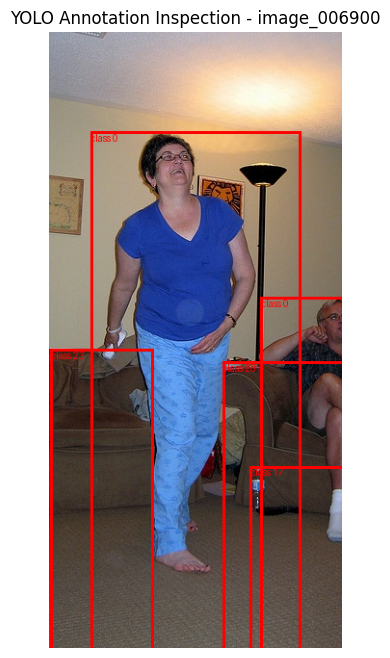

In [ ]:
from PIL import Image, ImageDraw
from pathlib import Path
import matplotlib.pyplot as plt

IMAGE_PATH = Path("/content/detection_clean/images/image_006900.jpg")
LABEL_PATH = Path("/content/detection_clean/labels/image_006900.txt")

image = Image.open(IMAGE_PATH).convert("RGB")

img_width, img_height = image.size

draw = ImageDraw.Draw(image)

with open(LABEL_PATH, "r") as f:
    lines = f.readlines()

for line in lines:

    values = line.strip().split()

    class_id = int(values[0])
    x_center = float(values[1])
    y_center = float(values[2])
    width = float(values[3])
    height = float(values[4])

    # Convert normalized YOLO coordinates to pixel coordinates
    x_center_px = x_center * img_width
    y_center_px = y_center * img_height

    box_width = width * img_width
    box_height = height * img_height

    x1 = x_center_px - box_width / 2
    y1 = y_center_px - box_height / 2
    x2 = x_center_px + box_width / 2
    y2 = y_center_px + box_height / 2

    draw.rectangle(
        [x1, y1, x2, y2],
        outline="red",
        width=3
    )

    draw.text(
        (x1, y1),
        f"class {class_id}",
        fill="red"
    )

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("YOLO Annotation Inspection - image_006900")
plt.show()

## 🧹 YOLO Annotation Boundary Correction

The duplicate-free dataset was further processed to prepare it for
YOLO object detection.

Some annotations contained bounding boxes extending beyond the image
boundaries. Instead of removing these objects, the bounding boxes were
converted from normalized YOLO coordinates to pixel coordinates and
clipped to the valid image boundaries.

The corrected bounding boxes were then converted back to normalized
YOLO format.

A separate dataset was created so that the original cleaned dataset
remains unchanged.

### Output

- Images: `/content/detection_yolo_ready/images`
- Labels: `/content/detection_yolo_ready/labels`

This dataset will be validated before YOLOv8 training.

In [ ]:
# ============================================================
# 🧹 CREATE YOLO-READY DATASET
# ============================================================

from pathlib import Path
from PIL import Image
import shutil

# Source dataset
SOURCE_DIR = Path("/content/detection_clean")

# New cleaned dataset
OUTPUT_DIR = Path("/content/detection_yolo_ready")

SOURCE_IMAGES = SOURCE_DIR / "images"
SOURCE_LABELS = SOURCE_DIR / "labels"

OUTPUT_IMAGES = OUTPUT_DIR / "images"
OUTPUT_LABELS = OUTPUT_DIR / "labels"

# Create directories
OUTPUT_IMAGES.mkdir(parents=True, exist_ok=True)
OUTPUT_LABELS.mkdir(parents=True, exist_ok=True)

total_images = 0
total_boxes = 0
corrected_boxes = 0
discarded_boxes = 0

image_files = sorted(SOURCE_IMAGES.glob("*.jpg"))

print("=" * 60)
print("🧹 CREATING YOLO-READY DATASET")
print("=" * 60)

for image_path in image_files:

    label_path = SOURCE_LABELS / f"{image_path.stem}.txt"

    # Read image dimensions
    with Image.open(image_path) as img:
        img_width, img_height = img.size

    new_labels = []

    # Read annotations
    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:

        values = line.strip().split()

        if len(values) != 5:
            continue

        class_id = int(values[0])

        x_center = float(values[1])
        y_center = float(values[2])
        width = float(values[3])
        height = float(values[4])

        total_boxes += 1

        # ----------------------------------------------------
        # YOLO normalized coordinates → pixel coordinates
        # ----------------------------------------------------

        x_center_px = x_center * img_width
        y_center_px = y_center * img_height

        width_px = width * img_width
        height_px = height * img_height

        x1 = x_center_px - width_px / 2
        y1 = y_center_px - height_px / 2
        x2 = x_center_px + width_px / 2
        y2 = y_center_px + height_px / 2

        # ----------------------------------------------------
        # Clip bounding box to image boundaries
        # ----------------------------------------------------

        original_box = (x1, y1, x2, y2)

        x1 = max(0, min(x1, img_width))
        y1 = max(0, min(y1, img_height))
        x2 = max(0, min(x2, img_width))
        y2 = max(0, min(y2, img_height))

        # Check whether clipping occurred
        if original_box != (x1, y1, x2, y2):
            corrected_boxes += 1

        # ----------------------------------------------------
        # Remove boxes that have no visible area
        # ----------------------------------------------------

        if x2 <= x1 or y2 <= y1:
            discarded_boxes += 1
            continue

        # ----------------------------------------------------
        # Pixel coordinates → YOLO normalized coordinates
        # ----------------------------------------------------

        new_x_center = ((x1 + x2) / 2) / img_width
        new_y_center = ((y1 + y2) / 2) / img_height

        new_width = (x2 - x1) / img_width
        new_height = (y2 - y1) / img_height

        new_labels.append(
            f"{class_id} "
            f"{new_x_center:.6f} "
            f"{new_y_center:.6f} "
            f"{new_width:.6f} "
            f"{new_height:.6f}\n"
        )

    # Copy image
    shutil.copy2(
        image_path,
        OUTPUT_IMAGES / image_path.name
    )

    # Save corrected labels
    with open(
        OUTPUT_LABELS / label_path.name,
        "w"
    ) as f:
        f.writelines(new_labels)

    total_images += 1

print("\n" + "=" * 60)
print("✅ YOLO-READY DATASET CREATED")
print("=" * 60)

print(f"Images processed       : {total_images}")
print(f"Total boxes            : {total_boxes}")
print(f"Boxes clipped          : {corrected_boxes}")
print(f"Boxes discarded        : {discarded_boxes}")

print(f"\n📁 Images : {OUTPUT_IMAGES}")
print(f"📁 Labels : {OUTPUT_LABELS}")

🧹 CREATING YOLO-READY DATASET

✅ YOLO-READY DATASET CREATED
Images processed       : 2995
Total boxes            : 17175
Boxes clipped          : 13437
Boxes discarded        : 0

📁 Images : /content/detection_yolo_ready/images
📁 Labels : /content/detection_yolo_ready/labels


## 🔎 YOLO Annotation Revalidation

After correcting bounding boxes that extended beyond image boundaries,
the complete YOLO-ready dataset was revalidated.

The validation checks that:

- Each annotation contains exactly five values.
- Class IDs are valid integers.
- Bounding-box center coordinates are normalized between 0 and 1.
- Bounding-box width and height are greater than 0 and at most 1.
- No malformed or empty annotation files remain.

Only after the annotations pass this validation will the dataset be
used for YOLO object detection training.

In [ ]:
# ============================================================
# 🔎 REVALIDATE YOLO-READY ANNOTATIONS
# ============================================================

from pathlib import Path

DATASET_DIR = Path("/content/detection_yolo_ready")
LABEL_DIR = DATASET_DIR / "labels"

total_labels = 0
total_boxes = 0
invalid_boxes = []
malformed_lines = 0
empty_labels = 0

for label_path in sorted(LABEL_DIR.glob("*.txt")):

    total_labels += 1

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    if len(lines) == 0:
        empty_labels += 1
        continue

    for line_number, line in enumerate(lines, start=1):

        values = line.split()

        if len(values) != 5:
            malformed_lines += 1
            continue

        try:
            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            width = float(values[3])
            height = float(values[4])
        except ValueError:
            malformed_lines += 1
            continue

        total_boxes += 1

        # YOLO normalized coordinates must be in [0, 1]
        if not (
            0 <= x_center <= 1 and
            0 <= y_center <= 1 and
            0 < width <= 1 and
            0 < height <= 1
        ):
            invalid_boxes.append(
                (label_path.name, line_number, line)
            )

print("=" * 60)
print("🔎 YOLO-READY ANNOTATION VALIDATION")
print("=" * 60)

print(f"Label files checked : {total_labels}")
print(f"Total boxes         : {total_boxes}")
print(f"Empty label files   : {empty_labels}")
print(f"Malformed lines     : {malformed_lines}")
print(f"Invalid boxes       : {len(invalid_boxes)}")

if len(invalid_boxes) == 0:
    print("\n✅ ALL YOLO ANNOTATIONS ARE VALID!")
else:
    print("\n⚠️ Invalid annotations still found.")
    print("\nFirst 10:")
    for item in invalid_boxes[:10]:
        print(item)

🔎 YOLO-READY ANNOTATION VALIDATION
Label files checked : 2995
Total boxes         : 17175
Empty label files   : 0
Malformed lines     : 0
Invalid boxes       : 0

✅ ALL YOLO ANNOTATIONS ARE VALID!


## 👁️ Visual Verification of Corrected YOLO Annotations

Random samples from the YOLO-ready dataset are visualized with their
bounding boxes.

This step verifies that the boundary correction process preserved
meaningful object annotations and that the bounding boxes are properly
aligned with the objects in the images.

The dataset will proceed to YOLOv8 training only after the annotations
are visually confirmed.

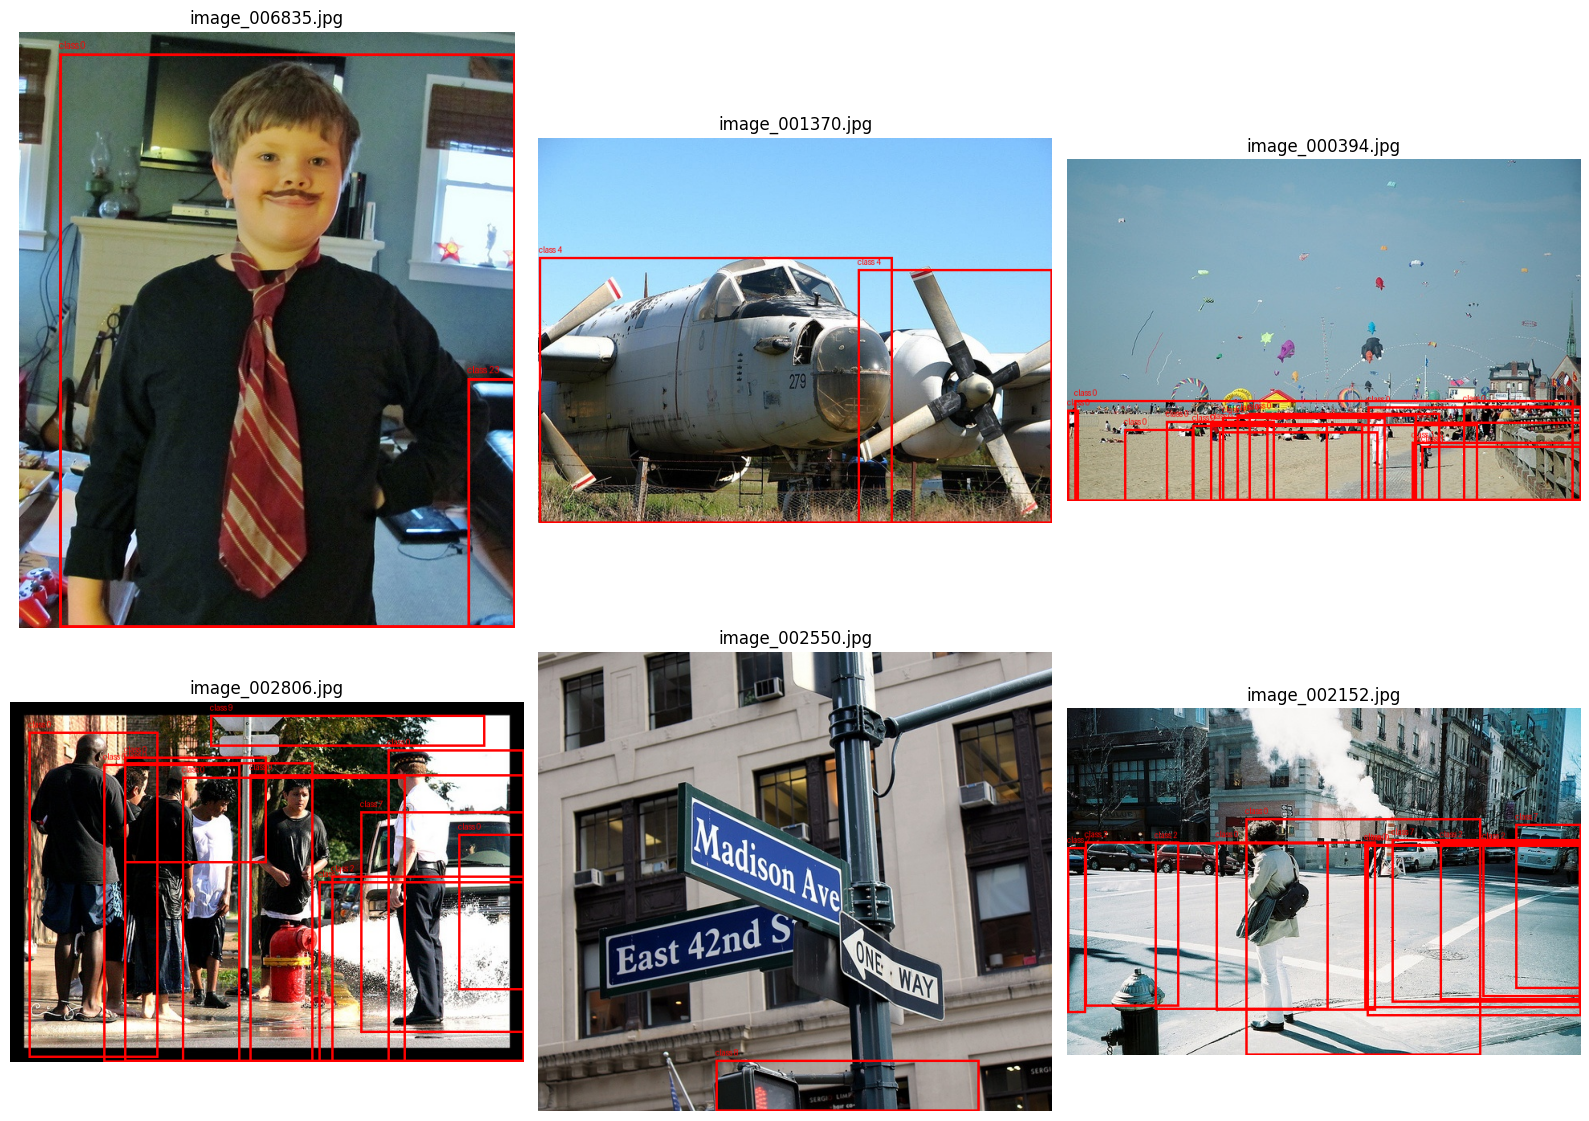

In [ ]:
# ============================================================
# 👁️ VISUALIZE CORRECTED YOLO ANNOTATIONS
# ============================================================

from pathlib import Path
from PIL import Image, ImageDraw
import random
import matplotlib.pyplot as plt

DATASET_DIR = Path("/content/detection_yolo_ready")
IMAGE_DIR = DATASET_DIR / "images"
LABEL_DIR = DATASET_DIR / "labels"

# Select random images
image_files = sorted(IMAGE_DIR.glob("*.jpg"))

random.seed(42)
selected_images = random.sample(image_files, min(6, len(image_files)))

plt.figure(figsize=(16, 12))

for i, image_path in enumerate(selected_images):

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    image = Image.open(image_path).convert("RGB")

    img_width, img_height = image.size

    draw = ImageDraw.Draw(image)

    # Read YOLO annotations
    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:

        values = line.strip().split()

        if len(values) != 5:
            continue

        class_id = int(values[0])

        x_center = float(values[1])
        y_center = float(values[2])
        width = float(values[3])
        height = float(values[4])

        # YOLO → pixel coordinates
        x_center_px = x_center * img_width
        y_center_px = y_center * img_height

        box_width = width * img_width
        box_height = height * img_height

        x1 = int(x_center_px - box_width / 2)
        y1 = int(y_center_px - box_height / 2)
        x2 = int(x_center_px + box_width / 2)
        y2 = int(y_center_px + box_height / 2)

        draw.rectangle(
            [x1, y1, x2, y2],
            outline="red",
            width=3
        )

        draw.text(
            (x1, max(0, y1 - 15)),
            f"class {class_id}",
            fill="red"
        )

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 💾 SAVE CLEANED YOLO DATASET TO GOOGLE DRIVE

from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Source cleaned dataset
source_dir = "/content/detection_yolo_ready"

# Destination ZIP in Google Drive
output_zip = "/content/drive/MyDrive/detection_yolo_ready"

# Create ZIP
shutil.make_archive(
    output_zip,
    'zip',
    source_dir
)

print("=" * 60)
print("✅ CLEANED YOLO DATASET SAVED!")
print("=" * 60)

print(f"📁 Source : {source_dir}")
print(f"💾 Saved  : {output_zip}.zip")

print("\n📦 Checking file...")
print(os.path.exists(output_zip + ".zip"))

if os.path.exists(output_zip + ".zip"):
    size_gb = os.path.getsize(output_zip + ".zip") / (1024 ** 3)
    print(f"📊 ZIP size: {size_gb:.2f} GB")
    print("✅ Ready for YOLO training!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ CLEANED YOLO DATASET SAVED!
📁 Source : /content/detection_yolo_ready
💾 Saved  : /content/drive/MyDrive/detection_yolo_ready.zip

📦 Checking file...
True
📊 ZIP size: 0.37 GB
✅ Ready for YOLO training!
